# Home Credit Default Risk — Model Development and Validation

## Project Objective

Build, validate, compare, calibrate, explain, and package robust credit-default classification models using the completed feature-engineering dataset.

## Prediction Problem

- Task: Binary classification
- Target: `TARGET`
- Positive class: Applicant default
- Identifier: `SK_ID_CURR`
- Primary ranking metric: ROC-AUC
- Mandatory secondary metrics: PR-AUC, Log Loss, Brier Score, KS, calibration slope, and calibration intercept

## Final Modelling Inputs

- Main feature set: Maximum information-preserving predictors
- Lean feature set: Reduced-redundancy performance predictors
- Compact feature set: Interpretable and faster experimental predictors
- Fairness-reduced feature set: Optional governance and sensitivity comparison

## Research Workflow

1. Verify the final datasets, environment, and hardware.
2. Freeze reproducible validation folds.
3. Establish simple risk baselines.
4. Screen linear, tree, bagging, and boosting model families.
5. Compare feature sets and feature-engineering blocks.
6. Tune only the strongest model families.
7. Generate final out-of-fold predictions.
8. Analyse calibration, thresholds, lift, and operational performance.
9. Build honest ensembles using out-of-fold predictions.
10. Audit robustness, drift, fairness, and explainability.
11. Lock the final configuration and create test predictions.

## Leakage Boundary

The following operations must be fitted only inside the appropriate training fold:

- Missing-value imputation
- Numerical scaling
- Categorical encoding
- Target or weight-of-evidence encoding
- Supervised binning or transformation
- Feature selection
- Probability calibration
- Ensemble-weight optimisation

The test dataset must never influence preprocessing, model selection, hyperparameter selection, calibration, or blending.

## Engineering Policy

- Use all available CPU resources where supported.
- Use the RTX 5060 Ti GPU for supported boosting models.
- Run one major GPU model at a time.
- Execute native GPU libraries in isolated worker processes during hardware calibration.
- Save every important result immediately after completion.
- Keep long-running experiments resumable.
- Record runtime, memory, feature count, and validation metrics for every model.

# Step 0 — Environment, Data, Hardware, and Runtime Calibration

## Objectives

- Configure reproducible global settings.
- Create the modelling output structure.
- Audit software, CPU, RAM, GPU, and CUDA visibility.
- Load and independently validate the final modelling datasets.
- Create a fixed 50,000-row runtime benchmark.
- Test CPU and GPU model compatibility without risking the notebook kernel.
- Estimate full-dataset model runtime from measured local performance.

## Important Boundary

Step 0 is a compatibility and engineering-calibration stage.

Benchmark scores from this step are not final validation results and must not be used to select the final model.

## Step 0.1 — Configure the Notebook and Define Small Helper Functions

### Actions

- Configure CPU thread usage and random seeds.
- Import mandatory and optional libraries.
- Define compact reporting, saving, metric, dtype, memory, and hardware helpers.
- Centralise notebook constants inside configuration dictionaries.

In [2]:
import os
import gc
import json
import time
import platform
import subprocess
import warnings
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

CPU_THREADS = os.cpu_count() or 8

for environment_variable in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ[environment_variable] = str(CPU_THREADS)

os.environ["PYTHONHASHSEED"] = "42"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import joblib

from IPython.display import display
from sklearn import __version__ as sklearn_version
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

CONFIG = {
    "random_state": 42,
    "n_jobs": -1,
    "gpu_device_id": 0,
    "benchmark_rows": 50_000,
    "benchmark_valid_size": 0.20,
    "benchmark_rounds": 1_500,
    "early_stopping_rounds": 50,
    "worker_timeout_seconds": 1_800,
    "notebook_version": "2.0"
}

np.random.seed(CONFIG["random_state"])
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

try:
    import psutil
    PSUTIL_AVAILABLE = True
except Exception:
    psutil = None
    PSUTIL_AVAILABLE = False

OPTIONAL_LIBRARIES = {}

for library_name in ["lightgbm", "xgboost", "catboost", "optuna"]:
    try:
        OPTIONAL_LIBRARIES[library_name] = {"available": True, "version": version(library_name)}
    except Exception:
        OPTIONAL_LIBRARIES[library_name] = {"available": False, "version": "NOT_INSTALLED"}

def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=2)

def package_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "NOT_INSTALLED"
    except Exception:
        return "UNKNOWN"

def dtype_family(dtype):
    if pd.api.types.is_bool_dtype(dtype):
        return "boolean"

    if pd.api.types.is_numeric_dtype(dtype):
        return "numeric"

    if pd.api.types.is_datetime64_any_dtype(dtype):
        return "datetime"

    if pd.api.types.is_object_dtype(dtype) or pd.api.types.is_string_dtype(dtype) or isinstance(dtype, pd.CategoricalDtype):
        return "categorical"

    return "unsupported"

def evaluate_probabilities(y_true, probability):
    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-7, 1 - 1e-7)

    return {
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "pr_auc": float(average_precision_score(y_true, probability)),
        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
        "brier_score": float(brier_score_loss(y_true, probability)),
        "prediction_mean": float(probability.mean())
    }

def process_memory_gb():
    if not PSUTIL_AVAILABLE:
        return np.nan

    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)

def show_report(title, values):
    print("=" * 94)
    print(title)

    for label, value in values:
        print(f"{label}: {value}")

    print("=" * 94)

def query_gpu():
    command = ["nvidia-smi", "--query-gpu=index,name,memory.total,memory.free,memory.used,driver_version", "--format=csv,noheader,nounits"]

    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True, timeout=30)
        records = []

        for line in result.stdout.strip().splitlines():
            values = [value.strip() for value in line.split(",")]

            if len(values) == 6:
                records.append({"gpu_index": int(values[0]), "gpu_name": values[1], "memory_total_mb": int(values[2]), "memory_free_mb": int(values[3]), "memory_used_mb": int(values[4]), "driver_version": values[5]})

        return pd.DataFrame(records), None

    except Exception as error:
        return pd.DataFrame(), f"{type(error).__name__}: {error}"

library_table = pd.DataFrame([{"library": library, **information} for library, information in OPTIONAL_LIBRARIES.items()])
display(library_table)

show_report("STEP 0.1 COMPLETE", [
    ("Random state", CONFIG["random_state"]),
    ("CPU thread policy", f"{CPU_THREADS} detected, n_jobs={CONFIG['n_jobs']}"),
    ("GPU device", CONFIG["gpu_device_id"]),
    ("Runtime benchmark rows", f"{CONFIG['benchmark_rows']:,}"),
    ("Worker isolation timeout", f"{CONFIG['worker_timeout_seconds']} seconds")
])

,library,available,version
0,lightgbm,True,4.7.0
1,xgboost,True,3.2.0
2,catboost,True,1.2.10
3,optuna,True,4.8.0


STEP 0.1 COMPLETE
Random state: 42
CPU thread policy: 16 detected, n_jobs=-1
GPU device: 0
Runtime benchmark rows: 50,000
Worker isolation timeout: 1800 seconds


## Step 0.2 — Define Paths and Audit the Modelling Environment

### Actions

- Define all project paths through compact dictionaries.
- Create the modelling output directories.
- Verify required feature-engineering inputs.
- Record package versions, CPU resources, RAM, GPU model, VRAM, and driver.
- Save reproducible path and environment manifests.

In [3]:
PROJECT_ROOT = Path(r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk")

DIRS = {
    "feature_package": PROJECT_ROOT / "Feature_engineering" / "final_package",
    "model_root": PROJECT_ROOT / "Model_training",
    "checkpoints": PROJECT_ROOT / "Model_training" / "checkpoints",
    "folds": PROJECT_ROOT / "Model_training" / "folds",
    "metrics": PROJECT_ROOT / "Model_training" / "metrics",
    "models": PROJECT_ROOT / "Model_training" / "models",
    "oof": PROJECT_ROOT / "Model_training" / "oof_predictions",
    "test_predictions": PROJECT_ROOT / "Model_training" / "test_predictions",
    "tuning": PROJECT_ROOT / "Model_training" / "tuning",
    "calibration": PROJECT_ROOT / "Model_training" / "calibration",
    "figures": PROJECT_ROOT / "Model_training" / "figures",
    "explanations": PROJECT_ROOT / "Model_training" / "explanations",
    "temporary_workers": PROJECT_ROOT / "Model_training" / "temporary_workers",
    "manifests": PROJECT_ROOT / "Model_training" / "manifests",
    "final_package": PROJECT_ROOT / "Model_training" / "final_package"
}

for directory in DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

PATHS = {
    "train": DIRS["feature_package"] / "data" / "train_feature_engineered.parquet",
    "test": DIRS["feature_package"] / "data" / "test_feature_engineered.parquet",
    "summary": DIRS["feature_package"] / "metadata" / "feature_engineering_summary.json",
    "validation": DIRS["feature_package"] / "metadata" / "final_validation_report.csv",
    "registry": DIRS["feature_package"] / "metadata" / "final_feature_registry.csv",
    "main_features": DIRS["feature_package"] / "metadata" / "main_feature_list.csv",
    "lean_features": DIRS["feature_package"] / "metadata" / "lean_feature_list.csv",
    "compact_features": DIRS["feature_package"] / "metadata" / "compact_feature_list.csv",
    "fairness_reduced": DIRS["feature_package"] / "metadata" / "fairness_reduced_feature_list.csv",
    "fairness_exclusion": DIRS["feature_package"] / "metadata" / "fairness_exclusion_list.csv",
    "review_watchlist": DIRS["feature_package"] / "metadata" / "feature_review_watchlist.csv"
}

required_inputs = ["train", "test", "summary", "validation", "registry", "main_features", "lean_features", "compact_features", "review_watchlist"]
missing_inputs = [str(PATHS[name]) for name in required_inputs if not PATHS[name].exists()]

assert not missing_inputs, f"Required modelling inputs are missing: {missing_inputs}"

gpu_table, gpu_error = query_gpu()

physical_cores = psutil.cpu_count(logical=False) if PSUTIL_AVAILABLE else None
logical_threads = psutil.cpu_count(logical=True) if PSUTIL_AVAILABLE else CPU_THREADS
memory = psutil.virtual_memory() if PSUTIL_AVAILABLE else None

ENVIRONMENT = {
    "notebook_version": CONFIG["notebook_version"],
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "operating_system": platform.platform(),
    "python": platform.python_version(),
    "physical_cpu_cores": physical_cores,
    "logical_cpu_threads": logical_threads,
    "total_ram_gb": round(memory.total / (1024 ** 3), 3) if memory else None,
    "available_ram_gb": round(memory.available / (1024 ** 3), 3) if memory else None,
    "gpu_detected": not gpu_table.empty,
    "gpu_query_error": gpu_error,
    "gpu_information": gpu_table.to_dict("records"),
    "packages": {
        "numpy": package_version("numpy"),
        "pandas": package_version("pandas"),
        "scikit_learn": sklearn_version,
        "pyarrow": package_version("pyarrow"),
        "lightgbm": package_version("lightgbm"),
        "xgboost": package_version("xgboost"),
        "catboost": package_version("catboost"),
        "optuna": package_version("optuna")
    }
}

save_json({name: str(path) for name, path in PATHS.items()}, DIRS["manifests"] / "path_manifest.json")
save_json(ENVIRONMENT, DIRS["manifests"] / "environment_manifest.json")

environment_table = pd.DataFrame([
    {"item": "Physical CPU cores", "value": physical_cores},
    {"item": "Logical CPU threads", "value": logical_threads},
    {"item": "Total RAM GB", "value": ENVIRONMENT["total_ram_gb"]},
    {"item": "Available RAM GB", "value": ENVIRONMENT["available_ram_gb"]},
    {"item": "GPU detected", "value": ENVIRONMENT["gpu_detected"]},
    {"item": "All CPU threads requested", "value": CONFIG["n_jobs"] == -1}
])

display(environment_table)

if not gpu_table.empty:
    display(gpu_table)

show_report("STEP 0.2 COMPLETE", [
    ("Required inputs verified", len(required_inputs)),
    ("Output directories created", len(DIRS)),
    ("Physical CPU cores", physical_cores),
    ("Logical CPU threads", logical_threads),
    ("Total RAM", f"{ENVIRONMENT['total_ram_gb']} GB"),
    ("GPU detected", ENVIRONMENT["gpu_detected"]),
    ("Environment manifest", DIRS["manifests"] / "environment_manifest.json")
])

,item,value
0,Physical CPU cores,8
1,Logical CPU threads,16
2,Total RAM GB,31.575000
3,Available RAM GB,17.366000
4,GPU detected,True
5,All CPU threads requested,True


,gpu_index,gpu_name,memory_total_mb,memory_free_mb,memory_used_mb,driver_version
0,0,NVIDIA GeForce RTX 5060 Ti,8151,6530,1273,576.88


STEP 0.2 COMPLETE
Required inputs verified: 9
Output directories created: 15
Physical CPU cores: 8
Logical CPU threads: 16
Total RAM: 31.575 GB
GPU detected: True
Environment manifest: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\manifests\environment_manifest.json


## Step 0.3 — Load and Independently Audit the Final Modelling Data

### Actions

- Load feature lists and final metadata.
- Load the final training and testing datasets once.
- Reconstruct the fairness-reduced list when it is not already available.
- Verify dimensions, predictor order, identifier integrity, target integrity, feature-set hierarchy, dtypes, and infinite values.
- Record target prevalence, memory use, and feature composition.

In [4]:
def load_feature_list(path):
    return pd.read_csv(path)["feature"].astype(str).tolist()

def count_infinite_values(dataframe, features, chunk_size=128):
    total = 0
    affected = []

    for start in range(0, len(features), chunk_size):
        chunk_features = features[start:start + chunk_size]
        values = dataframe[chunk_features].to_numpy(dtype=np.float64, na_value=np.nan, copy=True)
        counts = np.isinf(values).sum(axis=0)

        total += int(counts.sum())
        affected.extend([{"feature": feature, "infinite_count": int(count)} for feature, count in zip(chunk_features, counts) if count > 0])

        del values
        gc.collect()

    return total, pd.DataFrame(affected, columns=["feature", "infinite_count"])

with open(PATHS["summary"], "r", encoding="utf-8") as file:
    feature_engineering_summary = json.load(file)

final_validation = pd.read_csv(PATHS["validation"])
final_registry = pd.read_csv(PATHS["registry"])
review_watchlist = pd.read_csv(PATHS["review_watchlist"])

FEATURE_SETS = {
    "MAIN": load_feature_list(PATHS["main_features"]),
    "LEAN": load_feature_list(PATHS["lean_features"]),
    "COMPACT": load_feature_list(PATHS["compact_features"])
}

if PATHS["fairness_reduced"].exists():
    FEATURE_SETS["FAIRNESS_REDUCED"] = load_feature_list(PATHS["fairness_reduced"])
else:
    fairness_exclusions = set(load_feature_list(PATHS["fairness_exclusion"]))
    FEATURE_SETS["FAIRNESS_REDUCED"] = [feature for feature in FEATURE_SETS["MAIN"] if feature not in fairness_exclusions]

load_start = time.perf_counter()
DATA = {"train": pd.read_parquet(PATHS["train"]), "test": pd.read_parquet(PATHS["test"])}
load_seconds = time.perf_counter() - load_start

ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"

TARGET = DATA["train"][TARGET_COLUMN].astype("int8")
TRAIN_ID = DATA["train"][ID_COLUMN]
TEST_ID = DATA["test"][ID_COLUMN]

train_predictors = [column for column in DATA["train"].columns if column not in [ID_COLUMN, TARGET_COLUMN]]
test_predictors = [column for column in DATA["test"].columns if column != ID_COLUMN]

numeric_features = [feature for feature in FEATURE_SETS["MAIN"] if dtype_family(DATA["train"][feature].dtype) in {"numeric", "boolean"}]
categorical_features = [feature for feature in FEATURE_SETS["MAIN"] if dtype_family(DATA["train"][feature].dtype) == "categorical"]
unsupported_features = [feature for feature in FEATURE_SETS["MAIN"] if dtype_family(DATA["train"][feature].dtype) == "unsupported"]
dtype_mismatches = [feature for feature in FEATURE_SETS["MAIN"] if dtype_family(DATA["train"][feature].dtype) != dtype_family(DATA["test"][feature].dtype)]

train_infinite_count, train_infinite_detail = count_infinite_values(DATA["train"], numeric_features)
test_infinite_count, test_infinite_detail = count_infinite_values(DATA["test"], numeric_features)

audit_checks = {
    "FEATURE_ENGINEERING_COMPLETE": feature_engineering_summary["status"] == "FEATURE_ENGINEERING_COMPLETE",
    "FINAL_VALIDATION_PASS": final_validation["status"].eq("PASS").all(),
    "TRAIN_TEST_ALIGNMENT": train_predictors == test_predictors,
    "MAIN_MATCHES_DATASET": train_predictors == FEATURE_SETS["MAIN"],
    "LEAN_SUBSET_MAIN": set(FEATURE_SETS["LEAN"]).issubset(FEATURE_SETS["MAIN"]),
    "COMPACT_SUBSET_LEAN": set(FEATURE_SETS["COMPACT"]).issubset(FEATURE_SETS["LEAN"]),
    "FAIRNESS_SUBSET_MAIN": set(FEATURE_SETS["FAIRNESS_REDUCED"]).issubset(FEATURE_SETS["MAIN"]),
    "TRAIN_ID_UNIQUE": TRAIN_ID.is_unique,
    "TEST_ID_UNIQUE": TEST_ID.is_unique,
    "TARGET_ONLY_IN_TRAIN": TARGET_COLUMN not in DATA["test"].columns,
    "NO_UNSUPPORTED_DTYPES": len(unsupported_features) == 0,
    "NO_DTYPE_MISMATCH": len(dtype_mismatches) == 0,
    "NO_TRAIN_INFINITY": train_infinite_count == 0,
    "NO_TEST_INFINITY": test_infinite_count == 0
}

data_audit = pd.DataFrame([{"check": check, "status": "PASS" if passed else "FAIL"} for check, passed in audit_checks.items()])
data_audit.to_csv(DIRS["metrics"] / "step0_data_audit.csv", index=False)

infinite_audit = pd.concat([train_infinite_detail.assign(dataset="TRAIN"), test_infinite_detail.assign(dataset="TEST")], ignore_index=True)
infinite_audit.to_csv(DIRS["metrics"] / "step0_infinite_value_audit.csv", index=False)

assert all(audit_checks.values()), f"Data audit failed. Review: {DIRS['metrics'] / 'step0_data_audit.csv'}"

DATA_PROFILE = {
    "training_rows": len(DATA["train"]),
    "testing_rows": len(DATA["test"]),
    "training_columns": DATA["train"].shape[1],
    "testing_columns": DATA["test"].shape[1],
    "default_rate": float(TARGET.mean()),
    "imbalance_ratio": float(TARGET.eq(0).sum() / TARGET.eq(1).sum()),
    "numeric_features": len(numeric_features),
    "categorical_features": len(categorical_features),
    "train_memory_gb": float(DATA["train"].memory_usage(deep=True).sum() / (1024 ** 3)),
    "test_memory_gb": float(DATA["test"].memory_usage(deep=True).sum() / (1024 ** 3)),
    "load_seconds": load_seconds
}

feature_set_table = pd.DataFrame([{"feature_set": name, "feature_count": len(features)} for name, features in FEATURE_SETS.items()])
profile_table = pd.DataFrame([{"metric": metric, "value": value} for metric, value in DATA_PROFILE.items()])

display(data_audit)
display(feature_set_table)
display(profile_table)

show_report("STEP 0.3 COMPLETE", [
    ("Training shape", DATA["train"].shape),
    ("Testing shape", DATA["test"].shape),
    ("Default rate", f"{DATA_PROFILE['default_rate']:.6%}"),
    ("Main features", len(FEATURE_SETS["MAIN"])),
    ("Lean features", len(FEATURE_SETS["LEAN"])),
    ("Compact features", len(FEATURE_SETS["COMPACT"])),
    ("Combined memory", f"{DATA_PROFILE['train_memory_gb'] + DATA_PROFILE['test_memory_gb']:.3f} GB"),
    ("Infinite values", train_infinite_count + test_infinite_count)
])

,check,status
0,FEATURE_ENGINEERING_COMPLETE,PASS
1,FINAL_VALIDATION_PASS,PASS
2,TRAIN_TEST_ALIGNMENT,PASS
3,MAIN_MATCHES_DATASET,PASS
4,LEAN_SUBSET_MAIN,PASS
5,COMPACT_SUBSET_LEAN,PASS
6,FAIRNESS_SUBSET_MAIN,PASS
7,TRAIN_ID_UNIQUE,PASS
8,TEST_ID_UNIQUE,PASS
9,TARGET_ONLY_IN_TRAIN,PASS


,feature_set,feature_count
0,MAIN,2703
1,LEAN,2121
2,COMPACT,1369
3,FAIRNESS_REDUCED,2694


,metric,value
0,training_rows,"307,511.000000"
1,testing_rows,"48,744.000000"
2,training_columns,"2,705.000000"
3,testing_columns,"2,704.000000"
4,default_rate,0.080729
5,imbalance_ratio,11.387150
6,numeric_features,"2,687.000000"
7,categorical_features,16.000000
8,train_memory_gb,3.280668
9,test_memory_gb,0.520028


STEP 0.3 COMPLETE
Training shape: (307511, 2705)
Testing shape: (48744, 2704)
Default rate: 8.072882%
Main features: 2703
Lean features: 2121
Compact features: 1369
Combined memory: 3.801 GB
Infinite values: 0


## Step 0.4 — Create a Fixed Runtime Benchmark and Temporary Model Matrix

### Design

- Select 50,000 rows through stratified sampling.
- Preserve the original target prevalence.
- Split the sample into fixed training and validation partitions.
- Use the full Compact feature set.
- Convert categorical predictors to temporary training-derived numeric codes.
- Save memory-mapped `float32` arrays for isolated worker processes.

### Important Boundary

Temporary category codes are used only for hardware and runtime calibration.

Final model preprocessing will be fitted independently inside each training fold.

In [5]:
BENCHMARK_DIR = DIRS["temporary_workers"] / "step0_benchmark"
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)

BENCHMARK_PATHS = {
    "x_train": BENCHMARK_DIR / "X_train.npy",
    "x_valid": BENCHMARK_DIR / "X_valid.npy",
    "y_train": BENCHMARK_DIR / "y_train.npy",
    "y_valid": BENCHMARK_DIR / "y_valid.npy",
    "split": DIRS["checkpoints"] / "step0_runtime_benchmark_split.csv",
    "manifest": DIRS["checkpoints"] / "step0_runtime_benchmark_manifest.json"
}

def create_benchmark_arrays(dataframe, target, identifiers, features, row_count, valid_size, random_state):
    sample_split = StratifiedShuffleSplit(n_splits=1, train_size=min(row_count, len(dataframe)), random_state=random_state)
    sample_positions, _ = next(sample_split.split(np.zeros(len(dataframe), dtype=np.int8), target))

    sample_data = dataframe.iloc[sample_positions][features].reset_index(drop=True)
    sample_target = target.iloc[sample_positions].reset_index(drop=True)
    sample_ids = identifiers.iloc[sample_positions].reset_index(drop=True)

    train_valid_split = StratifiedShuffleSplit(n_splits=1, test_size=valid_size, random_state=random_state)
    train_positions, valid_positions = next(train_valid_split.split(np.zeros(len(sample_data), dtype=np.int8), sample_target))

    train_frame = sample_data.iloc[train_positions].reset_index(drop=True)
    valid_frame = sample_data.iloc[valid_positions].reset_index(drop=True)
    y_train = sample_target.iloc[train_positions].to_numpy(dtype=np.float32)
    y_valid = sample_target.iloc[valid_positions].to_numpy(dtype=np.float32)

    X_train = np.empty((len(train_frame), len(features)), dtype=np.float32)
    X_valid = np.empty((len(valid_frame), len(features)), dtype=np.float32)

    categorical_count = 0

    for feature_index, feature in enumerate(features):
        if dtype_family(train_frame[feature].dtype) in {"numeric", "boolean"}:
            X_train[:, feature_index] = pd.to_numeric(train_frame[feature], errors="coerce").to_numpy(dtype=np.float32, na_value=np.nan)
            X_valid[:, feature_index] = pd.to_numeric(valid_frame[feature], errors="coerce").to_numpy(dtype=np.float32, na_value=np.nan)
        else:
            training_values = train_frame[feature].astype("string")
            validation_values = valid_frame[feature].astype("string")
            categories = pd.Index(training_values.dropna().unique())

            train_codes = pd.Categorical(training_values, categories=categories).codes.astype(np.float32)
            valid_codes = pd.Categorical(validation_values, categories=categories).codes.astype(np.float32)

            train_codes[train_codes < 0] = np.nan
            valid_codes[valid_codes < 0] = np.nan

            X_train[:, feature_index] = train_codes
            X_valid[:, feature_index] = valid_codes
            categorical_count += 1

    split_registry = pd.concat([
        pd.DataFrame({ID_COLUMN: sample_ids.iloc[train_positions].to_numpy(), TARGET_COLUMN: y_train.astype(np.int8), "benchmark_split": "TRAIN"}),
        pd.DataFrame({ID_COLUMN: sample_ids.iloc[valid_positions].to_numpy(), TARGET_COLUMN: y_valid.astype(np.int8), "benchmark_split": "VALID"})
    ], ignore_index=True)

    manifest = {
        "training_rows": len(X_train),
        "validation_rows": len(X_valid),
        "feature_count": len(features),
        "categorical_features_encoded": categorical_count,
        "training_default_rate": float(y_train.mean()),
        "validation_default_rate": float(y_valid.mean()),
        "matrix_dtype": "float32"
    }

    return X_train, X_valid, y_train, y_valid, split_registry, manifest

preparation_start = time.perf_counter()

X_benchmark_train, X_benchmark_valid, y_benchmark_train, y_benchmark_valid, benchmark_split, BENCHMARK_MANIFEST = create_benchmark_arrays(
    DATA["train"],
    TARGET,
    TRAIN_ID,
    FEATURE_SETS["COMPACT"],
    CONFIG["benchmark_rows"],
    CONFIG["benchmark_valid_size"],
    CONFIG["random_state"]
)

np.save(BENCHMARK_PATHS["x_train"], X_benchmark_train)
np.save(BENCHMARK_PATHS["x_valid"], X_benchmark_valid)
np.save(BENCHMARK_PATHS["y_train"], y_benchmark_train)
np.save(BENCHMARK_PATHS["y_valid"], y_benchmark_valid)

benchmark_split.to_csv(BENCHMARK_PATHS["split"], index=False)
save_json(BENCHMARK_MANIFEST, BENCHMARK_PATHS["manifest"])

BENCHMARK_MANIFEST["preparation_seconds"] = time.perf_counter() - preparation_start

display(pd.DataFrame([BENCHMARK_MANIFEST]))

show_report("STEP 0.4 COMPLETE", [
    ("Training matrix", X_benchmark_train.shape),
    ("Validation matrix", X_benchmark_valid.shape),
    ("Matrix dtype", X_benchmark_train.dtype),
    ("Categorical features encoded", BENCHMARK_MANIFEST["categorical_features_encoded"]),
    ("Preparation time", f"{BENCHMARK_MANIFEST['preparation_seconds']:.2f} seconds"),
    ("Benchmark directory", BENCHMARK_DIR)
])

del X_benchmark_train, X_benchmark_valid, y_benchmark_train, y_benchmark_valid
gc.collect()

,training_rows,validation_rows,feature_count,categorical_features_encoded,training_default_rate,validation_default_rate,matrix_dtype,preparation_seconds
0,40000,10000,1369,16,0.080725,0.080700,float32,1.508998


STEP 0.4 COMPLETE
Training matrix: (40000, 1369)
Validation matrix: (10000, 1369)
Matrix dtype: float32
Categorical features encoded: 16
Preparation time: 1.51 seconds
Benchmark directory: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\temporary_workers\step0_benchmark


62

## Step 0.5 — Run Isolated CPU and GPU Runtime Benchmarks

### Models

- Logistic Regression on all CPU threads
- LightGBM using CUDA or GPU backend
- XGBoost using CUDA histogram training and QuantileDMatrix
- CatBoost using GPU device 0

### Isolation Policy

Each model runs inside a separate Python process.

A native CUDA or C++ failure can terminate only that worker process and cannot terminate the Jupyter kernel.

### Output

- Compatibility status
- Worker return code
- Fit and prediction time
- Best iteration
- ROC-AUC
- PR-AUC
- Log Loss
- Brier Score

In [6]:
WORKER_SCRIPT_PATH = DIRS["temporary_workers"] / "step0_model_worker.py"
RUNTIME_RESULTS_PATH = DIRS["metrics"] / "step0_runtime_calibration_results.csv"

worker_code = r'''
import os
import sys
import gc
import json
import time
import traceback
import warnings

import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

model_name = sys.argv[1]
x_train_path = sys.argv[2]
x_valid_path = sys.argv[3]
y_train_path = sys.argv[4]
y_valid_path = sys.argv[5]
result_path = sys.argv[6]
prediction_path = sys.argv[7]
max_rounds = int(sys.argv[8])
early_stopping = int(sys.argv[9])

result = {"model": model_name, "status": "STARTED"}

def metrics(y_true, probability):
    probability = np.clip(np.asarray(probability, dtype=np.float64), 1e-7, 1 - 1e-7)

    return {
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "pr_auc": float(average_precision_score(y_true, probability)),
        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
        "brier_score": float(brier_score_loss(y_true, probability)),
        "prediction_mean": float(probability.mean())
    }

try:
    X_train = np.load(x_train_path, mmap_mode="r")
    X_valid = np.load(x_valid_path, mmap_mode="r")
    y_train = np.load(y_train_path, mmap_mode="r")
    y_valid = np.load(y_valid_path, mmap_mode="r")

    matrix_seconds = np.nan
    best_iteration = np.nan
    backend = "UNKNOWN"

    if model_name == "LOGISTIC_CPU":
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False)),
            ("model", LogisticRegression(solver="saga", penalty="l2", C=1.0, max_iter=300, n_jobs=-1, random_state=42))
        ])

        fit_start = time.perf_counter()
        model.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - fit_start

        prediction_start = time.perf_counter()
        probability = model.predict_proba(X_valid)[:, 1]
        prediction_seconds = time.perf_counter() - prediction_start

        best_iteration = int(np.max(model.named_steps["model"].n_iter_))
        backend = "CPU_ALL_THREADS"

    elif model_name == "LIGHTGBM_GPU":
        from lightgbm import LGBMClassifier, early_stopping, log_evaluation

        errors = []

        for device_type in ["cuda", "gpu"]:
            try:
                model = LGBMClassifier(objective="binary", n_estimators=max_rounds, learning_rate=0.05, num_leaves=31, min_child_samples=50, subsample=0.80, subsample_freq=1, colsample_bytree=0.80, reg_lambda=1.0, random_state=42, n_jobs=-1, device_type=device_type, verbosity=-1)

                fit_start = time.perf_counter()
                model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], eval_metric="auc", callbacks=[early_stopping(early_stopping_rounds=early_stopping, verbose=False), log_evaluation(0)])
                fit_seconds = time.perf_counter() - fit_start

                prediction_start = time.perf_counter()
                probability = model.predict_proba(X_valid)[:, 1]
                prediction_seconds = time.perf_counter() - prediction_start

                best_iteration = int(model.best_iteration_ or max_rounds)
                backend = device_type.upper()
                break

            except Exception as error:
                errors.append(f"{device_type}: {type(error).__name__}: {error}")
                model = None
                gc.collect()

        if model is None:
            raise RuntimeError(" | ".join(errors))

    elif model_name == "XGBOOST_GPU":
        import xgboost as xgb

        matrix_start = time.perf_counter()
        dtrain = xgb.QuantileDMatrix(X_train, y_train, max_bin=128, missing=np.nan)
        dvalid = xgb.QuantileDMatrix(X_valid, y_valid, ref=dtrain, max_bin=128, missing=np.nan)
        matrix_seconds = time.perf_counter() - matrix_start

        parameters = {"objective": "binary:logistic", "eval_metric": ["auc", "logloss"], "tree_method": "hist", "device": "cuda:0", "learning_rate": 0.05, "max_depth": 6, "min_child_weight": 5.0, "subsample": 0.80, "colsample_bytree": 0.80, "reg_lambda": 1.0, "max_bin": 128, "nthread": os.cpu_count() or 8, "seed": 42}

        fit_start = time.perf_counter()
        model = xgb.train(parameters, dtrain, num_boost_round=max_rounds, evals=[(dvalid, "valid")], early_stopping_rounds=early_stopping, verbose_eval=False)
        fit_seconds = time.perf_counter() - fit_start

        best_iteration = int(getattr(model, "best_iteration", max_rounds - 1))

        prediction_start = time.perf_counter()
        probability = model.predict(dvalid, iteration_range=(0, best_iteration + 1))
        prediction_seconds = time.perf_counter() - prediction_start

        backend = "HIST_CUDA_QUANTILE_DMAT"

    elif model_name == "CATBOOST_GPU":
        from catboost import CatBoostClassifier

        model = CatBoostClassifier(iterations=max_rounds, learning_rate=0.05, depth=7, loss_function="Logloss", eval_metric="AUC", random_seed=42, task_type="GPU", devices="0", thread_count=-1, gpu_ram_part=0.95, border_count=128, od_type="Iter", od_wait=early_stopping, verbose=False, allow_writing_files=False)

        fit_start = time.perf_counter()
        model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True, verbose=False)
        fit_seconds = time.perf_counter() - fit_start

        prediction_start = time.perf_counter()
        probability = model.predict_proba(X_valid)[:, 1]
        prediction_seconds = time.perf_counter() - prediction_start

        best_iteration = int(model.get_best_iteration())
        backend = "GPU_0"

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    probability = np.asarray(probability, dtype=np.float32)
    np.save(prediction_path, probability)

    result = {
        "model": model_name,
        "status": "PASS",
        "backend": backend,
        "training_rows": int(X_train.shape[0]),
        "validation_rows": int(X_valid.shape[0]),
        "feature_count": int(X_train.shape[1]),
        "matrix_seconds": float(matrix_seconds) if np.isfinite(matrix_seconds) else None,
        "fit_seconds": float(fit_seconds),
        "prediction_seconds": float(prediction_seconds),
        "best_iteration": int(best_iteration),
        **metrics(y_valid, probability)
    }

except Exception as error:
    result = {
        "model": model_name,
        "status": "ERROR",
        "error_type": type(error).__name__,
        "error": str(error),
        "traceback": traceback.format_exc()
    }

with open(result_path, "w", encoding="utf-8") as file:
    json.dump(result, file, indent=2)
'''

WORKER_SCRIPT_PATH.write_text(worker_code, encoding="utf-8")

def run_isolated_benchmark(model_name):
    worker_directory = DIRS["temporary_workers"] / model_name.lower()
    worker_directory.mkdir(parents=True, exist_ok=True)

    result_path = worker_directory / "result.json"
    prediction_path = worker_directory / "prediction.npy"
    stdout_path = worker_directory / "stdout.log"
    stderr_path = worker_directory / "stderr.log"

    for path in [result_path, prediction_path, stdout_path, stderr_path]:
        if path.exists():
            path.unlink()

    command = [
        os.sys.executable,
        str(WORKER_SCRIPT_PATH),
        model_name,
        str(BENCHMARK_PATHS["x_train"]),
        str(BENCHMARK_PATHS["x_valid"]),
        str(BENCHMARK_PATHS["y_train"]),
        str(BENCHMARK_PATHS["y_valid"]),
        str(result_path),
        str(prediction_path),
        str(CONFIG["benchmark_rounds"]),
        str(CONFIG["early_stopping_rounds"])
    ]

    worker_environment = os.environ.copy()
    worker_environment["CUDA_VISIBLE_DEVICES"] = str(CONFIG["gpu_device_id"])

    start = time.perf_counter()

    try:
        process = subprocess.run(command, capture_output=True, text=True, timeout=CONFIG["worker_timeout_seconds"], env=worker_environment)
        return_code = process.returncode
        stdout = process.stdout or ""
        stderr = process.stderr or ""
        timeout = False

    except subprocess.TimeoutExpired as error:
        return_code = None
        stdout = error.stdout.decode(errors="replace") if isinstance(error.stdout, bytes) else (error.stdout or "")
        stderr = error.stderr.decode(errors="replace") if isinstance(error.stderr, bytes) else (error.stderr or "")
        timeout = True

    elapsed_seconds = time.perf_counter() - start

    stdout_path.write_text(stdout, encoding="utf-8", errors="replace")
    stderr_path.write_text(stderr, encoding="utf-8", errors="replace")

    if result_path.exists():
        with open(result_path, "r", encoding="utf-8") as file:
            result = json.load(file)
    else:
        result = {"model": model_name, "status": "NATIVE_PROCESS_FAILURE"}

    result.update({
        "worker_return_code": return_code,
        "worker_timeout": timeout,
        "worker_total_seconds": elapsed_seconds,
        "stdout_log": str(stdout_path),
        "stderr_log": str(stderr_path)
    })

    return result

benchmark_models = ["LOGISTIC_CPU", "LIGHTGBM_GPU", "XGBOOST_GPU", "CATBOOST_GPU"]
runtime_results = pd.DataFrame([run_isolated_benchmark(model_name) for model_name in benchmark_models])

runtime_results.to_csv(RUNTIME_RESULTS_PATH, index=False)
display(runtime_results)

show_report("STEP 0.5 COMPLETE", [
    ("Benchmarks executed", len(runtime_results)),
    ("Successful benchmarks", int(runtime_results["status"].eq("PASS").sum())),
    ("Failed or crashed benchmarks", int(runtime_results["status"].ne("PASS").sum())),
    ("Jupyter kernel protected", True),
    ("Runtime results", RUNTIME_RESULTS_PATH)
])

,model,status,backend,training_rows,validation_rows,feature_count,matrix_seconds,fit_seconds,prediction_seconds,best_iteration,roc_auc,pr_auc,log_loss,brier_score,prediction_mean,worker_return_code,worker_timeout,worker_total_seconds,stdout_log,stderr_log,error_type,error,traceback
0,LOGISTIC_CPU,PASS,CPU_ALL_THREADS,"40,000.000000","10,000.000000","1,369.000000",NaN,76.391763,0.173893,300.000000,0.766943,0.233172,0.245584,0.068252,0.081099,0,False,77.914062,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,NaN,NaN,NaN
1,LIGHTGBM_GPU,ERROR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,1.308924,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,RuntimeError,cuda: TypeError: early_stopping() got an unexp...,"Traceback (most recent call last):\n File ""C:..."
2,XGBOOST_GPU,PASS,HIST_CUDA_QUANTILE_DMAT,"40,000.000000","10,000.000000","1,369.000000",1.385764,2.309500,0.007909,124.000000,0.771625,0.249279,0.242814,0.067330,0.078183,0,False,5.071626,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,NaN,NaN,NaN
3,CATBOOST_GPU,PASS,GPU_0,"40,000.000000","10,000.000000","1,369.000000",NaN,39.050992,0.030906,266.000000,0.774039,0.245925,0.243125,0.067538,0.079352,0,False,40.813682,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,NaN,NaN,NaN


STEP 0.5 COMPLETE
Benchmarks executed: 4
Successful benchmarks: 3
Failed or crashed benchmarks: 1
Jupyter kernel protected: True
Runtime results: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\metrics\step0_runtime_calibration_results.csv


## Step 0.6 — Finalise Runtime Calibration and Save the Step 0 Checkpoint

### Actions

- Consolidate measured CPU and GPU benchmark results.
- Estimate Compact, Lean, and Main discovery-fit runtime.
- Estimate five-fold runtime ranges for successful models.
- Record available model backends.
- Save the final Step 0 checkpoint and runtime projection.
- Remove large temporary benchmark arrays after all results are saved.

### Runtime Boundary

Runtime projections are conservative engineering estimates.

Actual duration will depend on early stopping, model complexity, GPU backend efficiency, and final hyperparameters.

In [7]:
def build_runtime_projection(results, feature_sets, benchmark_manifest, full_training_rows):
    exponent_map = {
        "LOGISTIC_CPU": 0.90,
        "LIGHTGBM_GPU": 0.65,
        "XGBOOST_GPU": 0.75,
        "CATBOOST_GPU": 0.75
    }

    row_scale = int(full_training_rows * 0.80) / benchmark_manifest["training_rows"]
    compact_count = len(feature_sets["COMPACT"])
    rows = []

    for result in results.loc[results["status"].eq("PASS")].itertuples(index=False):
        exponent = exponent_map.get(result.model, 0.75)

        for feature_set, features in feature_sets.items():
            if feature_set == "FAIRNESS_REDUCED":
                continue

            feature_scale = (len(features) / compact_count) ** exponent
            central_minutes = result.fit_seconds * row_scale * feature_scale / 60

            rows.append({
                "model": result.model,
                "backend": result.backend,
                "feature_set": feature_set,
                "projected_discovery_minutes_low": central_minutes * 0.75,
                "projected_discovery_minutes_central": central_minutes,
                "projected_discovery_minutes_high": central_minutes * 1.75,
                "projected_five_fold_hours_low": central_minutes * 5 * 0.75 / 60,
                "projected_five_fold_hours_central": central_minutes * 5 / 60,
                "projected_five_fold_hours_high": central_minutes * 5 * 1.75 / 60
            })

    return pd.DataFrame(rows)

runtime_results = pd.read_csv(RUNTIME_RESULTS_PATH)
runtime_projection = build_runtime_projection(runtime_results, FEATURE_SETS, BENCHMARK_MANIFEST, len(DATA["train"]))

runtime_projection.to_csv(DIRS["metrics"] / "step0_runtime_projection.csv", index=False)

cpu_passes = int(runtime_results.loc[runtime_results["model"].eq("LOGISTIC_CPU"), "status"].eq("PASS").sum())
gpu_passes = int(runtime_results.loc[runtime_results["model"].isin(["LIGHTGBM_GPU", "XGBOOST_GPU", "CATBOOST_GPU"]), "status"].eq("PASS").sum())
gpu_failures = int(runtime_results.loc[runtime_results["model"].isin(["LIGHTGBM_GPU", "XGBOOST_GPU", "CATBOOST_GPU"]), "status"].ne("PASS").sum())

if cpu_passes == 1 and gpu_passes >= 1:
    step0_status = "STEP_0_COMPLETE"
elif cpu_passes == 1:
    step0_status = "STEP_0_COMPLETE_WITH_GPU_WARNING"
else:
    step0_status = "STEP_0_INCOMPLETE"

STEP0_SUMMARY = {
    "status": step0_status,
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "data_profile": DATA_PROFILE,
    "feature_sets": {name: len(features) for name, features in FEATURE_SETS.items()},
    "benchmark_manifest": BENCHMARK_MANIFEST,
    "cpu_benchmark_passes": cpu_passes,
    "gpu_benchmark_passes": gpu_passes,
    "gpu_benchmark_failures": gpu_failures,
    "runtime_results": str(RUNTIME_RESULTS_PATH),
    "runtime_projection": str(DIRS["metrics"] / "step0_runtime_projection.csv"),
    "environment_manifest": str(DIRS["manifests"] / "environment_manifest.json"),
    "next_step": "STEP_1_EXPERIMENTAL_DESIGN_AND_FROZEN_FOLDS"
}

save_json(STEP0_SUMMARY, DIRS["checkpoints"] / "step0_summary.json")

display(runtime_results[["model", "backend", "status", "fit_seconds", "prediction_seconds", "best_iteration", "roc_auc", "pr_auc", "log_loss", "brier_score", "worker_return_code"]])
display(runtime_projection)

temporary_array_paths = [BENCHMARK_PATHS["x_train"], BENCHMARK_PATHS["x_valid"], BENCHMARK_PATHS["y_train"], BENCHMARK_PATHS["y_valid"]]

for temporary_path in temporary_array_paths:
    if temporary_path.exists():
        temporary_path.unlink()

gc.collect()

show_report("STEP 0 COMPLETE — ENVIRONMENT, DATA, HARDWARE, AND RUNTIME CALIBRATION FINISHED", [
    ("Step 0 status", step0_status),
    ("Training shape", DATA["train"].shape),
    ("Testing shape", DATA["test"].shape),
    ("Main features", len(FEATURE_SETS["MAIN"])),
    ("Lean features", len(FEATURE_SETS["LEAN"])),
    ("Compact features", len(FEATURE_SETS["COMPACT"])),
    ("Default rate", f"{DATA_PROFILE['default_rate']:.6%}"),
    ("CPU benchmark passes", cpu_passes),
    ("GPU benchmark passes", gpu_passes),
    ("GPU benchmark failures", gpu_failures),
    ("Runtime results", RUNTIME_RESULTS_PATH),
    ("Step 0 checkpoint", DIRS["checkpoints"] / "step0_summary.json"),
    ("Next step", "STEP 1 — EXPERIMENTAL DESIGN AND FROZEN FOLD REGISTRY")
])

,model,backend,status,fit_seconds,prediction_seconds,best_iteration,roc_auc,pr_auc,log_loss,brier_score,worker_return_code
0,LOGISTIC_CPU,CPU_ALL_THREADS,PASS,76.391763,0.173893,300.000000,0.766943,0.233172,0.245584,0.068252,0
1,LIGHTGBM_GPU,NaN,ERROR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,XGBOOST_GPU,HIST_CUDA_QUANTILE_DMAT,PASS,2.309500,0.007909,124.000000,0.771625,0.249279,0.242814,0.067330,0
3,CATBOOST_GPU,GPU_0,PASS,39.050992,0.030906,266.000000,0.774039,0.245925,0.243125,0.067538,0


,model,backend,feature_set,projected_discovery_minutes_low,projected_discovery_minutes_central,projected_discovery_minutes_high,projected_five_fold_hours_low,projected_five_fold_hours_central,projected_five_fold_hours_high
0,LOGISTIC_CPU,CPU_ALL_THREADS,MAIN,10.832885,14.443846,25.276731,0.902740,1.203654,2.106394
1,LOGISTIC_CPU,CPU_ALL_THREADS,LEAN,8.709020,11.612027,20.321047,0.725752,0.967669,1.693421
2,LOGISTIC_CPU,CPU_ALL_THREADS,COMPACT,5.872808,7.830410,13.703218,0.489401,0.652534,1.141935
3,XGBOOST_GPU,HIST_CUDA_QUANTILE_DMAT,MAIN,0.295733,0.394310,0.690043,0.024644,0.032859,0.057504
4,XGBOOST_GPU,HIST_CUDA_QUANTILE_DMAT,LEAN,0.246559,0.328745,0.575303,0.020547,0.027395,0.047942
5,XGBOOST_GPU,HIST_CUDA_QUANTILE_DMAT,COMPACT,0.177549,0.236731,0.414280,0.014796,0.019728,0.034523
6,CATBOOST_GPU,GPU_0,MAIN,5.000498,6.667331,11.667829,0.416708,0.555611,0.972319
7,CATBOOST_GPU,GPU_0,LEAN,4.169022,5.558697,9.727719,0.347419,0.463225,0.810643
8,CATBOOST_GPU,GPU_0,COMPACT,3.002143,4.002857,7.004999,0.250179,0.333571,0.583750


STEP 0 COMPLETE — ENVIRONMENT, DATA, HARDWARE, AND RUNTIME CALIBRATION FINISHED
Step 0 status: STEP_0_COMPLETE
Training shape: (307511, 2705)
Testing shape: (48744, 2704)
Main features: 2703
Lean features: 2121
Compact features: 1369
Default rate: 8.072882%
CPU benchmark passes: 1
GPU benchmark passes: 2
GPU benchmark failures: 1
Runtime results: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\metrics\step0_runtime_calibration_results.csv
Step 0 checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\checkpoints\step0_summary.json
Next step: STEP 1 — EXPERIMENTAL DESIGN AND FROZEN FOLD REGISTRY


# Step 1 — Experimental Design, Frozen Validation Registry, and Leakage Control

## Objectives

- Define the evaluation and experiment contracts for the complete modelling notebook.
- Create one immutable stratified five-fold registry.
- Reserve one fold as a sealed final lockbox.
- Define a fast discovery split using only development data.
- Define four-fold development cross-validation for model confirmation.
- Verify fold balance, identifier integrity, target alignment, and role isolation.
- Create a standard result schema for all future models.
- Save all validation rules and registries for reproducible reuse.

## Validation Architecture

The labelled training dataset is divided into five frozen stratified folds:

- Folds 0–3: Development pool
- Fold 4: Sealed final lockbox

Within the development pool:

- Fold 0: Discovery validation
- Folds 1–3: Discovery training

Final model confirmation uses four-fold cross-validation across development folds 0–3.

The sealed lockbox must remain unavailable during model screening, feature-set comparison, hyperparameter tuning, calibration selection, and ensemble-weight optimisation.

## Important Boundary

This step does not train or select a predictive model.

It creates the experimental foundation that every later modelling step must follow.

## Step 1.1 — Define the Evaluation Contract and Reusable Split Logic

### Actions

- Restore the minimal Step 0 state when the kernel has been restarted.
- Define the development and lockbox architecture.
- Define model-evaluation metrics and their optimisation directions.
- Define standard experiment-stage labels.
- Define the common result schema used by all future models.
- Create reusable helpers for dataset signatures, immutable fold creation, and split access.

### Lockbox Protection

The reusable split function refuses to return lockbox rows unless explicit lockbox access is requested.

In [8]:
import os
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.ticker import PercentFormatter
from sklearn.model_selection import StratifiedKFold

PROJECT_ROOT = globals().get("PROJECT_ROOT", Path(r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk"))

if "DIRS" not in globals():
    DIRS = {
        "feature_package": PROJECT_ROOT / "Feature_engineering" / "final_package",
        "model_root": PROJECT_ROOT / "Model_training",
        "checkpoints": PROJECT_ROOT / "Model_training" / "checkpoints",
        "folds": PROJECT_ROOT / "Model_training" / "folds",
        "metrics": PROJECT_ROOT / "Model_training" / "metrics",
        "figures": PROJECT_ROOT / "Model_training" / "figures",
        "manifests": PROJECT_ROOT / "Model_training" / "manifests"
    }

for directory in DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

if "PATHS" not in globals():
    PATHS = {
        "train": DIRS["feature_package"] / "data" / "train_feature_engineered.parquet",
        "main_features": DIRS["feature_package"] / "metadata" / "main_feature_list.csv",
        "lean_features": DIRS["feature_package"] / "metadata" / "lean_feature_list.csv",
        "compact_features": DIRS["feature_package"] / "metadata" / "compact_feature_list.csv",
        "fairness_reduced": DIRS["feature_package"] / "metadata" / "fairness_reduced_feature_list.csv",
        "fairness_exclusion": DIRS["feature_package"] / "metadata" / "fairness_exclusion_list.csv"
    }

if "CONFIG" not in globals():
    CONFIG = {"random_state": 42, "n_jobs": -1}

ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"

if "TARGET" not in globals() or "TRAIN_ID" not in globals():
    identity_data = pd.read_parquet(PATHS["train"], columns=[ID_COLUMN, TARGET_COLUMN])
    TRAIN_ID = identity_data[ID_COLUMN].reset_index(drop=True)
    TARGET = identity_data[TARGET_COLUMN].astype("int8").reset_index(drop=True)
    del identity_data
else:
    TRAIN_ID = TRAIN_ID.reset_index(drop=True)
    TARGET = TARGET.astype("int8").reset_index(drop=True)

if "FEATURE_SETS" not in globals():
    FEATURE_SETS = {
        "MAIN": pd.read_csv(PATHS["main_features"])["feature"].astype(str).tolist(),
        "LEAN": pd.read_csv(PATHS["lean_features"])["feature"].astype(str).tolist(),
        "COMPACT": pd.read_csv(PATHS["compact_features"])["feature"].astype(str).tolist()
    }

    if PATHS["fairness_reduced"].exists():
        FEATURE_SETS["FAIRNESS_REDUCED"] = pd.read_csv(PATHS["fairness_reduced"])["feature"].astype(str).tolist()
    else:
        fairness_exclusions = set(pd.read_csv(PATHS["fairness_exclusion"])["feature"].astype(str))
        FEATURE_SETS["FAIRNESS_REDUCED"] = [feature for feature in FEATURE_SETS["MAIN"] if feature not in fairness_exclusions]

if "show_report" not in globals():
    def show_report(title, values):
        print("=" * 96)
        print(title)

        for label, value in values:
            print(f"{label}: {value}")

        print("=" * 96)

VALIDATION_DESIGN = {
    "outer_folds": 5,
    "development_folds": [0, 1, 2, 3],
    "lockbox_fold": 4,
    "discovery_train_folds": [1, 2, 3],
    "discovery_valid_fold": 0,
    "random_state": int(CONFIG["random_state"])
}

EVALUATION_CONTRACT = {
    "primary_metric": {"name": "ROC-AUC", "direction": "MAXIMISE"},
    "secondary_metrics": [
        {"name": "PR-AUC", "direction": "MAXIMISE"},
        {"name": "KS Statistic", "direction": "MAXIMISE"},
        {"name": "Log Loss", "direction": "MINIMISE"},
        {"name": "Brier Score", "direction": "MINIMISE"},
        {"name": "Calibration Slope Error", "direction": "MINIMISE"},
        {"name": "Calibration Intercept Error", "direction": "MINIMISE"}
    ],
    "engineering_metrics": [
        {"name": "Fit Time", "direction": "MINIMISE"},
        {"name": "Prediction Time", "direction": "MINIMISE"},
        {"name": "Model Size", "direction": "MINIMISE"},
        {"name": "Feature Count", "direction": "MINIMISE"}
    ],
    "final_performance_source": "SEALED_LOCKBOX",
    "test_data_policy": "TEST DATA MUST NOT INFLUENCE MODEL OR PREPROCESSING SELECTION"
}

EXPERIMENT_PROTOCOLS = {
    "DISCOVERY": {
        "training_folds": [1, 2, 3],
        "validation_folds": [0],
        "purpose": "Fast model-family, feature-set, and broad parameter screening",
        "final_claim_allowed": False
    },
    "DEVELOPMENT_CV": {
        "training_folds": "THREE OF DEVELOPMENT FOLDS 0-3",
        "validation_folds": "REMAINING DEVELOPMENT FOLD",
        "purpose": "Model confirmation, tuning confirmation, calibration development, and blending",
        "final_claim_allowed": False
    },
    "LOCKBOX": {
        "training_folds": [0, 1, 2, 3],
        "validation_folds": [4],
        "purpose": "One-time final assessment after configuration lock",
        "final_claim_allowed": True
    },
    "FULL_REFIT": {
        "training_folds": [0, 1, 2, 3, 4],
        "validation_folds": [],
        "purpose": "Final full-data refit and test prediction",
        "final_claim_allowed": False
    }
}

RESULT_SCHEMA = [
    "model_id", "model_family", "stage", "protocol", "feature_set", "fold", "training_rows", "validation_rows", "feature_count",
    "roc_auc", "pr_auc", "log_loss", "brier_score", "ks_statistic", "calibration_slope", "calibration_intercept",
    "fit_seconds", "prediction_seconds", "best_iteration", "parameter_id", "prediction_path", "model_path", "status", "notes"
]

def build_dataset_signature(identifiers, target):
    id_values = np.ascontiguousarray(identifiers.to_numpy(dtype=np.int64))
    target_values = np.ascontiguousarray(target.to_numpy(dtype=np.int8))

    return {
        "row_count": int(len(identifiers)),
        "positive_count": int(target_values.sum()),
        "negative_count": int(len(target_values) - target_values.sum()),
        "first_id": int(id_values[0]),
        "last_id": int(id_values[-1]),
        "id_dtype": str(id_values.dtype),
        "target_dtype": str(target_values.dtype),
        "id_hash": hashlib.blake2b(id_values.tobytes(), digest_size=16).hexdigest(),
        "target_hash": hashlib.blake2b(target_values.tobytes(), digest_size=16).hexdigest()
    }

def save_or_validate_fold_registry(registry_path, manifest_path, identifiers, target, dataset_signature, validation_design):
    registry_path = Path(registry_path)
    manifest_path = Path(manifest_path)

    if registry_path.exists() or manifest_path.exists():
        if not registry_path.exists() or not manifest_path.exists():
            raise RuntimeError("The frozen registry and its manifest must either both exist or both be absent.")

        registry = pd.read_parquet(registry_path)

        with open(manifest_path, "r", encoding="utf-8") as file:
            manifest = json.load(file)

        if manifest.get("dataset_signature") != dataset_signature:
            raise RuntimeError("The saved fold registry belongs to a different training dataset or row order.")

        if manifest.get("validation_design") != validation_design:
            raise RuntimeError("The saved fold registry uses a different validation design.")

        registry_source = "REUSED_EXISTING_REGISTRY"

    else:
        fold_values = np.full(len(target), -1, dtype=np.int8)
        splitter = StratifiedKFold(n_splits=validation_design["outer_folds"], shuffle=True, random_state=validation_design["random_state"])

        for fold, (_, validation_positions) in enumerate(splitter.split(np.zeros(len(target), dtype=np.int8), target)):
            fold_values[validation_positions] = fold

        development_mask = np.isin(fold_values, validation_design["development_folds"])
        lockbox_mask = fold_values == validation_design["lockbox_fold"]

        registry = pd.DataFrame({
            "row_position": np.arange(len(target), dtype=np.int32),
            ID_COLUMN: identifiers.to_numpy(),
            TARGET_COLUMN: target.to_numpy(dtype=np.int8),
            "outer_fold": fold_values,
            "dataset_role": np.where(development_mask, "DEVELOPMENT", "LOCKBOX"),
            "discovery_role": np.select(
                [np.isin(fold_values, validation_design["discovery_train_folds"]), fold_values == validation_design["discovery_valid_fold"], lockbox_mask],
                ["TRAIN", "VALID", "LOCKBOX"],
                default="UNASSIGNED"
            ),
            "development_fold": np.where(development_mask, fold_values, -1).astype(np.int8)
        })

        registry.to_parquet(registry_path, index=False)

        manifest = {
            "status": "FROZEN",
            "created_utc": pd.Timestamp.utcnow().isoformat(),
            "registry_path": str(registry_path),
            "dataset_signature": dataset_signature,
            "validation_design": validation_design
        }

        with open(manifest_path, "w", encoding="utf-8") as file:
            json.dump(manifest, file, indent=2)

        registry_source = "CREATED_NEW_REGISTRY"

    required_columns = ["row_position", ID_COLUMN, TARGET_COLUMN, "outer_fold", "dataset_role", "discovery_role", "development_fold"]
    missing_columns = [column for column in required_columns if column not in registry.columns]

    if missing_columns:
        raise RuntimeError(f"The frozen fold registry is missing columns: {missing_columns}")

    if len(registry) != len(identifiers):
        raise RuntimeError("The frozen fold registry row count does not match the training dataset.")

    if not np.array_equal(registry[ID_COLUMN].to_numpy(), identifiers.to_numpy()):
        raise RuntimeError("The frozen fold registry applicant order does not match the training dataset.")

    if not np.array_equal(registry[TARGET_COLUMN].to_numpy(dtype=np.int8), target.to_numpy(dtype=np.int8)):
        raise RuntimeError("The frozen fold registry target values do not match the training dataset.")

    return registry, registry_source

def get_split_positions(protocol, validation_fold=None, allow_lockbox=False):
    if "FOLD_REGISTRY" not in globals():
        raise RuntimeError("The frozen fold registry has not been created or loaded.")

    fold_values = FOLD_REGISTRY["outer_fold"].to_numpy(dtype=np.int8)

    if protocol == "DISCOVERY":
        train_mask = np.isin(fold_values, VALIDATION_DESIGN["discovery_train_folds"])
        valid_mask = fold_values == VALIDATION_DESIGN["discovery_valid_fold"]

    elif protocol == "DEVELOPMENT_CV":
        if validation_fold not in VALIDATION_DESIGN["development_folds"]:
            raise ValueError(f"validation_fold must be one of {VALIDATION_DESIGN['development_folds']}.")

        train_mask = np.isin(fold_values, [fold for fold in VALIDATION_DESIGN["development_folds"] if fold != validation_fold])
        valid_mask = fold_values == validation_fold

    elif protocol == "LOCKBOX":
        if not allow_lockbox:
            raise PermissionError("Lockbox access is blocked. Use allow_lockbox=True only after the final configuration is locked.")

        train_mask = np.isin(fold_values, VALIDATION_DESIGN["development_folds"])
        valid_mask = fold_values == VALIDATION_DESIGN["lockbox_fold"]

    elif protocol == "FULL_REFIT":
        train_mask = np.ones(len(fold_values), dtype=bool)
        valid_mask = np.zeros(len(fold_values), dtype=bool)

    else:
        raise ValueError(f"Unknown protocol: {protocol}")

    return np.flatnonzero(train_mask), np.flatnonzero(valid_mask)

protocol_table = pd.DataFrame([
    {"protocol": protocol, "training_folds": str(details["training_folds"]), "validation_folds": str(details["validation_folds"]), "purpose": details["purpose"], "final_claim_allowed": details["final_claim_allowed"]}
    for protocol, details in EXPERIMENT_PROTOCOLS.items()
])

display(protocol_table)

show_report("STEP 1.1 COMPLETE", [
    ("Training rows available", f"{len(TARGET):,}"),
    ("Validation folds", VALIDATION_DESIGN["outer_folds"]),
    ("Development folds", VALIDATION_DESIGN["development_folds"]),
    ("Sealed lockbox fold", VALIDATION_DESIGN["lockbox_fold"]),
    ("Defined experiment protocols", len(EXPERIMENT_PROTOCOLS)),
    ("Common result fields", len(RESULT_SCHEMA))
])

,protocol,training_folds,validation_folds,purpose,final_claim_allowed
0,DISCOVERY,"[1, 2, 3]",[0],"Fast model-family, feature-set, and broad para...",False
1,DEVELOPMENT_CV,THREE OF DEVELOPMENT FOLDS 0-3,REMAINING DEVELOPMENT FOLD,"Model confirmation, tuning confirmation, calib...",False
2,LOCKBOX,"[0, 1, 2, 3]",[4],One-time final assessment after configuration ...,True
3,FULL_REFIT,"[0, 1, 2, 3, 4]",[],Final full-data refit and test prediction,False


STEP 1.1 COMPLETE
Training rows available: 307,511
Validation folds: 5
Development folds: [0, 1, 2, 3]
Sealed lockbox fold: 4
Defined experiment protocols: 4
Common result fields: 24


## Step 1.2 — Create or Reuse the Immutable Five-Fold Registry

### Actions

- Build a deterministic signature of the current training dataset.
- Create five stratified folds when no registry exists.
- Reuse the existing registry when its dataset signature and validation design match.
- Refuse to overwrite or silently regenerate an incompatible registry.
- Preserve applicant row positions, identifiers, targets, folds, and experiment roles.

### Primary Output

- `frozen_fold_registry.parquet`
- `fold_registry_manifest.json`

In [9]:
FOLD_REGISTRY_PATH = DIRS["folds"] / "frozen_fold_registry.parquet"
FOLD_MANIFEST_PATH = DIRS["manifests"] / "fold_registry_manifest.json"

DATASET_SIGNATURE = build_dataset_signature(TRAIN_ID, TARGET)

FOLD_REGISTRY, FOLD_REGISTRY_SOURCE = save_or_validate_fold_registry(
    FOLD_REGISTRY_PATH,
    FOLD_MANIFEST_PATH,
    TRAIN_ID,
    TARGET,
    DATASET_SIGNATURE,
    VALIDATION_DESIGN
)

signature_table = pd.DataFrame([{"item": item, "value": value} for item, value in DATASET_SIGNATURE.items()])

registry_role_counts = FOLD_REGISTRY.groupby(["dataset_role", "discovery_role"], observed=True).size().reset_index(name="rows")

display(signature_table)
display(registry_role_counts)

discovery_train_positions, discovery_valid_positions = get_split_positions("DISCOVERY")

show_report("STEP 1.2 COMPLETE", [
    ("Registry source", FOLD_REGISTRY_SOURCE),
    ("Registry rows", f"{len(FOLD_REGISTRY):,}"),
    ("Discovery training rows", f"{len(discovery_train_positions):,}"),
    ("Discovery validation rows", f"{len(discovery_valid_positions):,}"),
    ("Registry path", FOLD_REGISTRY_PATH),
    ("Manifest path", FOLD_MANIFEST_PATH)
])

,item,value
0,row_count,307511
1,positive_count,24825
2,negative_count,282686
3,first_id,100002
4,last_id,456255
5,id_dtype,int64
6,target_dtype,int8
7,id_hash,aa75ee14e4a2a5901d905f30d4593e71
8,target_hash,b9741d63a1f878540b99362cd9f7e830


,dataset_role,discovery_role,rows
0,DEVELOPMENT,TRAIN,184506
1,DEVELOPMENT,VALID,61503
2,LOCKBOX,LOCKBOX,61502


STEP 1.2 COMPLETE
Registry source: CREATED_NEW_REGISTRY
Registry rows: 307,511
Discovery training rows: 184,506
Discovery validation rows: 61,503
Registry path: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\folds\frozen_fold_registry.parquet
Manifest path: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\manifests\fold_registry_manifest.json


## Step 1.3 — Audit Fold Balance, Target Stratification, and Role Isolation

### Structural Checks

- Every training applicant appears exactly once.
- Applicant and target order match the source dataset.
- Fold labels are complete and limited to 0–4.
- Development and lockbox rows do not overlap.
- Discovery training and validation rows do not overlap.
- Lockbox rows are unavailable to discovery experiments.
- Fold sizes are balanced.
- Fold-level target rates remain close to the overall target rate.

### Outputs

- Fold balance summary
- Validation-role summary
- Step 1 validation report
- Default-rate-by-fold figure

,outer_fold,rows,defaults,non_defaults,default_rate,absolute_rate_deviation,dataset_role
0,0,61503,4965,56538,0.080728,0.000001,DEVELOPMENT
1,1,61502,4965,56537,0.080729,0.000000,DEVELOPMENT
2,2,61502,4965,56537,0.080729,0.000000,DEVELOPMENT
3,3,61502,4965,56537,0.080729,0.000000,DEVELOPMENT
4,4,61502,4965,56537,0.080729,0.000000,LOCKBOX


,validation_role,rows,defaults,non_defaults,default_rate
0,DISCOVERY_TRAIN,184506,14895,169611,0.080729
1,DISCOVERY_VALID,61503,4965,56538,0.080728
2,DEVELOPMENT_POOL,246009,19860,226149,0.080729
3,LOCKBOX,61502,4965,56537,0.080729
4,FULL_LABELLED,307511,24825,282686,0.080729


,check,status,observed
0,REGISTRY_ROW_COUNT,PASS,307511
1,ROW_POSITION_COMPLETENESS,PASS,307511
2,IDENTIFIER_UNIQUENESS,PASS,307511
3,IDENTIFIER_ORDER_MATCH,PASS,307511
4,TARGET_ORDER_MATCH,PASS,24825
5,EXPECTED_FOLD_VALUES,PASS,"[0, 1, 2, 3, 4]"
6,FOLD_SIZE_BALANCE,PASS,1
7,TARGET_RATE_TOLERANCE,PASS,0.000001
8,DATASET_ROLE_MAPPING,PASS,2
9,DISCOVERY_ROLE_MAPPING,PASS,3


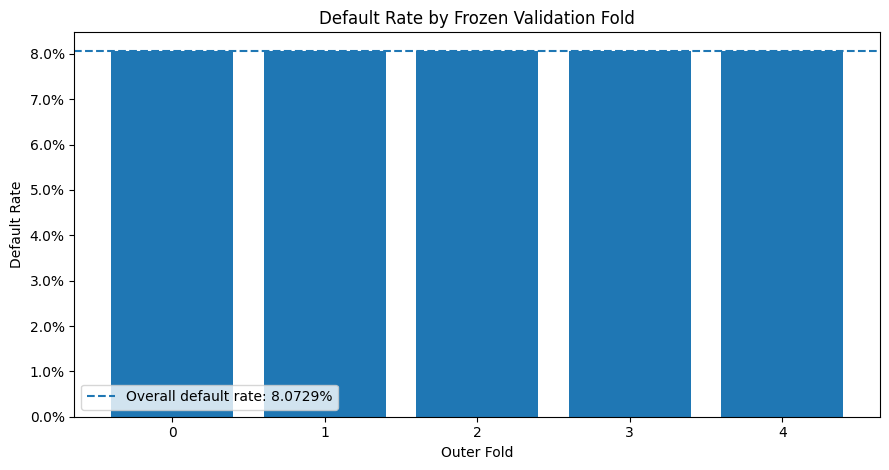

STEP 1.3 COMPLETE
Audit checks passed: 15 of 15
Maximum fold-size difference: 1
Maximum target-rate deviation: 0.00010501%
Minimum defaults in one fold: 4965
Lockbox rows: 61,502
Fold-balance figure: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\figures\step1_fold_default_rates.png


In [10]:
overall_default_rate = float(TARGET.mean())

fold_balance = FOLD_REGISTRY.groupby("outer_fold", observed=True).agg(
    rows=(ID_COLUMN, "size"),
    defaults=(TARGET_COLUMN, "sum")
).reset_index()

fold_balance["non_defaults"] = fold_balance["rows"] - fold_balance["defaults"]
fold_balance["default_rate"] = fold_balance["defaults"] / fold_balance["rows"]
fold_balance["absolute_rate_deviation"] = (fold_balance["default_rate"] - overall_default_rate).abs()
fold_balance["dataset_role"] = np.where(fold_balance["outer_fold"].isin(VALIDATION_DESIGN["development_folds"]), "DEVELOPMENT", "LOCKBOX")

role_masks = {
    "DISCOVERY_TRAIN": FOLD_REGISTRY["discovery_role"].eq("TRAIN").to_numpy(),
    "DISCOVERY_VALID": FOLD_REGISTRY["discovery_role"].eq("VALID").to_numpy(),
    "DEVELOPMENT_POOL": FOLD_REGISTRY["dataset_role"].eq("DEVELOPMENT").to_numpy(),
    "LOCKBOX": FOLD_REGISTRY["dataset_role"].eq("LOCKBOX").to_numpy(),
    "FULL_LABELLED": np.ones(len(FOLD_REGISTRY), dtype=bool)
}

role_rows = []

for role, mask in role_masks.items():
    role_target = FOLD_REGISTRY.loc[mask, TARGET_COLUMN]

    role_rows.append({
        "validation_role": role,
        "rows": int(mask.sum()),
        "defaults": int(role_target.sum()),
        "non_defaults": int(len(role_target) - role_target.sum()),
        "default_rate": float(role_target.mean())
    })

validation_role_summary = pd.DataFrame(role_rows)

fold_values = FOLD_REGISTRY["outer_fold"].to_numpy(dtype=np.int8)
row_positions = FOLD_REGISTRY["row_position"].to_numpy(dtype=np.int32)

development_positions = set(FOLD_REGISTRY.loc[FOLD_REGISTRY["dataset_role"].eq("DEVELOPMENT"), "row_position"])
lockbox_positions = set(FOLD_REGISTRY.loc[FOLD_REGISTRY["dataset_role"].eq("LOCKBOX"), "row_position"])
discovery_train_set = set(FOLD_REGISTRY.loc[FOLD_REGISTRY["discovery_role"].eq("TRAIN"), "row_position"])
discovery_valid_set = set(FOLD_REGISTRY.loc[FOLD_REGISTRY["discovery_role"].eq("VALID"), "row_position"])

expected_dataset_role = np.where(np.isin(fold_values, VALIDATION_DESIGN["development_folds"]), "DEVELOPMENT", "LOCKBOX")
expected_discovery_role = np.select(
    [np.isin(fold_values, VALIDATION_DESIGN["discovery_train_folds"]), fold_values == VALIDATION_DESIGN["discovery_valid_fold"], fold_values == VALIDATION_DESIGN["lockbox_fold"]],
    ["TRAIN", "VALID", "LOCKBOX"],
    default="UNASSIGNED"
)
expected_development_fold = np.where(np.isin(fold_values, VALIDATION_DESIGN["development_folds"]), fold_values, -1).astype(np.int8)

audit_items = [
    {"check": "REGISTRY_ROW_COUNT", "status": "PASS" if len(FOLD_REGISTRY) == len(TARGET) else "FAIL", "observed": len(FOLD_REGISTRY)},
    {"check": "ROW_POSITION_COMPLETENESS", "status": "PASS" if np.array_equal(row_positions, np.arange(len(TARGET), dtype=np.int32)) else "FAIL", "observed": int(pd.Series(row_positions).nunique())},
    {"check": "IDENTIFIER_UNIQUENESS", "status": "PASS" if FOLD_REGISTRY[ID_COLUMN].is_unique else "FAIL", "observed": FOLD_REGISTRY[ID_COLUMN].nunique()},
    {"check": "IDENTIFIER_ORDER_MATCH", "status": "PASS" if np.array_equal(FOLD_REGISTRY[ID_COLUMN].to_numpy(), TRAIN_ID.to_numpy()) else "FAIL", "observed": len(FOLD_REGISTRY)},
    {"check": "TARGET_ORDER_MATCH", "status": "PASS" if np.array_equal(FOLD_REGISTRY[TARGET_COLUMN].to_numpy(dtype=np.int8), TARGET.to_numpy(dtype=np.int8)) else "FAIL", "observed": int(FOLD_REGISTRY[TARGET_COLUMN].sum())},
    {"check": "EXPECTED_FOLD_VALUES", "status": "PASS" if set(fold_values) == set(range(VALIDATION_DESIGN["outer_folds"])) else "FAIL", "observed": sorted(set(fold_values))},
    {"check": "FOLD_SIZE_BALANCE", "status": "PASS" if int(fold_balance["rows"].max() - fold_balance["rows"].min()) <= 1 else "FAIL", "observed": int(fold_balance["rows"].max() - fold_balance["rows"].min())},
    {"check": "TARGET_RATE_TOLERANCE", "status": "PASS" if float(fold_balance["absolute_rate_deviation"].max()) <= 0.001 else "FAIL", "observed": float(fold_balance["absolute_rate_deviation"].max())},
    {"check": "DATASET_ROLE_MAPPING", "status": "PASS" if np.array_equal(FOLD_REGISTRY["dataset_role"].to_numpy(), expected_dataset_role) else "FAIL", "observed": FOLD_REGISTRY["dataset_role"].nunique()},
    {"check": "DISCOVERY_ROLE_MAPPING", "status": "PASS" if np.array_equal(FOLD_REGISTRY["discovery_role"].to_numpy(), expected_discovery_role) else "FAIL", "observed": FOLD_REGISTRY["discovery_role"].nunique()},
    {"check": "DEVELOPMENT_FOLD_MAPPING", "status": "PASS" if np.array_equal(FOLD_REGISTRY["development_fold"].to_numpy(dtype=np.int8), expected_development_fold) else "FAIL", "observed": sorted(FOLD_REGISTRY["development_fold"].unique())},
    {"check": "DEVELOPMENT_LOCKBOX_ISOLATION", "status": "PASS" if development_positions.isdisjoint(lockbox_positions) else "FAIL", "observed": len(development_positions.intersection(lockbox_positions))},
    {"check": "DISCOVERY_TRAIN_VALID_ISOLATION", "status": "PASS" if discovery_train_set.isdisjoint(discovery_valid_set) else "FAIL", "observed": len(discovery_train_set.intersection(discovery_valid_set))},
    {"check": "DISCOVERY_LOCKBOX_ISOLATION", "status": "PASS" if discovery_train_set.isdisjoint(lockbox_positions) and discovery_valid_set.isdisjoint(lockbox_positions) else "FAIL", "observed": len((discovery_train_set | discovery_valid_set).intersection(lockbox_positions))},
    {"check": "POSITIVE_SUPPORT_IN_EVERY_FOLD", "status": "PASS" if fold_balance["defaults"].gt(0).all() else "FAIL", "observed": int(fold_balance["defaults"].min())}
]

step1_validation_report = pd.DataFrame(audit_items)

fold_balance.to_csv(DIRS["folds"] / "fold_balance_summary.csv", index=False)
validation_role_summary.to_csv(DIRS["folds"] / "validation_role_summary.csv", index=False)
step1_validation_report.to_csv(DIRS["metrics"] / "step1_validation_report.csv", index=False)

assert step1_validation_report["status"].eq("PASS").all(), f"Step 1 validation failed. Review: {DIRS['metrics'] / 'step1_validation_report.csv'}"

display(fold_balance)
display(validation_role_summary)
display(step1_validation_report)

figure_path = DIRS["figures"] / "step1_fold_default_rates.png"

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(fold_balance["outer_fold"].astype(str), fold_balance["default_rate"])
ax.axhline(overall_default_rate, linestyle="--", linewidth=1.5, label=f"Overall default rate: {overall_default_rate:.4%}")
ax.set_title("Default Rate by Frozen Validation Fold")
ax.set_xlabel("Outer Fold")
ax.set_ylabel("Default Rate")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
fig.tight_layout()
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

show_report("STEP 1.3 COMPLETE", [
    ("Audit checks passed", f"{step1_validation_report['status'].eq('PASS').sum()} of {len(step1_validation_report)}"),
    ("Maximum fold-size difference", int(fold_balance["rows"].max() - fold_balance["rows"].min())),
    ("Maximum target-rate deviation", f"{fold_balance['absolute_rate_deviation'].max():.8%}"),
    ("Minimum defaults in one fold", int(fold_balance["defaults"].min())),
    ("Lockbox rows", f"{len(lockbox_positions):,}"),
    ("Fold-balance figure", figure_path)
])

## Step 1.4 — Save the Experiment Contracts and Seal the Final Lockbox

### Actions

- Save the evaluation and experiment contracts.
- Create or validate the lockbox-control file.
- Preserve an already-used lockbox state during notebook reruns.
- Create the standard model-comparison registry without overwriting prior results.
- Save the complete Step 1 checkpoint.

### Experiment Stages

- `SMOKE_TEST`: Compatibility and code testing only
- `DISCOVERY_SCREENING`: Fast family and feature-set screening
- `DEVELOPMENT_CONFIRMATION`: Four-fold development validation
- `LOCKBOX_FINAL_EVALUATION`: One-time final assessment
- `FULL_DATA_REFIT`: Final model trained on all labelled rows

In [11]:
EVALUATION_CONTRACT_PATH = DIRS["manifests"] / "evaluation_contract.json"
EXPERIMENT_PROTOCOL_PATH = DIRS["manifests"] / "experiment_protocols.json"
LOCKBOX_CONTROL_PATH = DIRS["manifests"] / "lockbox_control.json"
MODEL_COMPARISON_PATH = DIRS["metrics"] / "model_comparison_master.csv"
STEP1_SUMMARY_PATH = DIRS["checkpoints"] / "step1_summary.json"

with open(EVALUATION_CONTRACT_PATH, "w", encoding="utf-8") as file:
    json.dump(EVALUATION_CONTRACT, file, indent=2)

with open(EXPERIMENT_PROTOCOL_PATH, "w", encoding="utf-8") as file:
    json.dump(EXPERIMENT_PROTOCOLS, file, indent=2)

if LOCKBOX_CONTROL_PATH.exists():
    with open(LOCKBOX_CONTROL_PATH, "r", encoding="utf-8") as file:
        LOCKBOX_CONTROL = json.load(file)

    if LOCKBOX_CONTROL.get("lockbox_fold") != VALIDATION_DESIGN["lockbox_fold"]:
        raise RuntimeError("The existing lockbox-control file refers to a different lockbox fold.")

    if LOCKBOX_CONTROL.get("status") not in ["SEALED", "USED_ONCE"]:
        raise RuntimeError("The existing lockbox-control file contains an invalid status.")

else:
    LOCKBOX_CONTROL = {
        "status": "SEALED",
        "evaluation_count": 0,
        "lockbox_fold": VALIDATION_DESIGN["lockbox_fold"],
        "allowed_stage": "LOCKBOX_FINAL_EVALUATION",
        "sealed_utc": pd.Timestamp.utcnow().isoformat(),
        "used_utc": None,
        "selected_model_id": None
    }

    with open(LOCKBOX_CONTROL_PATH, "w", encoding="utf-8") as file:
        json.dump(LOCKBOX_CONTROL, file, indent=2)

if MODEL_COMPARISON_PATH.exists():
    existing_result_columns = pd.read_csv(MODEL_COMPARISON_PATH, nrows=0).columns.tolist()
    missing_result_columns = [column for column in RESULT_SCHEMA if column not in existing_result_columns]

    if missing_result_columns:
        raise RuntimeError(f"The existing model-comparison registry is missing columns: {missing_result_columns}")

    comparison_registry_status = "EXISTING_REGISTRY_PRESERVED"

else:
    pd.DataFrame(columns=RESULT_SCHEMA).to_csv(MODEL_COMPARISON_PATH, index=False)
    comparison_registry_status = "EMPTY_REGISTRY_CREATED"

protocol_rows = []

for protocol, details in EXPERIMENT_PROTOCOLS.items():
    protocol_rows.append({
        "protocol": protocol,
        "training_folds": str(details["training_folds"]),
        "validation_folds": str(details["validation_folds"]),
        "purpose": details["purpose"],
        "final_claim_allowed": details["final_claim_allowed"]
    })

protocol_summary = pd.DataFrame(protocol_rows)

development_mask = FOLD_REGISTRY["dataset_role"].eq("DEVELOPMENT")
lockbox_mask = FOLD_REGISTRY["dataset_role"].eq("LOCKBOX")
discovery_train_mask = FOLD_REGISTRY["discovery_role"].eq("TRAIN")
discovery_valid_mask = FOLD_REGISTRY["discovery_role"].eq("VALID")

STEP1_SUMMARY = {
    "status": "STEP_1_COMPLETE",
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "training_rows": int(len(FOLD_REGISTRY)),
    "development_rows": int(development_mask.sum()),
    "lockbox_rows": int(lockbox_mask.sum()),
    "discovery_training_rows": int(discovery_train_mask.sum()),
    "discovery_validation_rows": int(discovery_valid_mask.sum()),
    "overall_default_rate": overall_default_rate,
    "development_folds": VALIDATION_DESIGN["development_folds"],
    "lockbox_fold": VALIDATION_DESIGN["lockbox_fold"],
    "registry_source": FOLD_REGISTRY_SOURCE,
    "audit_checks_passed": int(step1_validation_report["status"].eq("PASS").sum()),
    "audit_checks_failed": int(step1_validation_report["status"].ne("PASS").sum()),
    "lockbox_status": LOCKBOX_CONTROL["status"],
    "model_comparison_registry_status": comparison_registry_status,
    "fold_registry": str(FOLD_REGISTRY_PATH),
    "fold_manifest": str(FOLD_MANIFEST_PATH),
    "evaluation_contract": str(EVALUATION_CONTRACT_PATH),
    "experiment_protocols": str(EXPERIMENT_PROTOCOL_PATH),
    "lockbox_control": str(LOCKBOX_CONTROL_PATH),
    "model_comparison_registry": str(MODEL_COMPARISON_PATH),
    "next_step": "STEP_2_BASELINE_RISK_MODELS"
}

with open(STEP1_SUMMARY_PATH, "w", encoding="utf-8") as file:
    json.dump(STEP1_SUMMARY, file, indent=2)

display(protocol_summary)

checkpoint_table = pd.DataFrame([
    {"item": "Training rows", "value": len(FOLD_REGISTRY)},
    {"item": "Development rows", "value": int(development_mask.sum())},
    {"item": "Lockbox rows", "value": int(lockbox_mask.sum())},
    {"item": "Discovery training rows", "value": int(discovery_train_mask.sum())},
    {"item": "Discovery validation rows", "value": int(discovery_valid_mask.sum())},
    {"item": "Development folds", "value": str(VALIDATION_DESIGN["development_folds"])},
    {"item": "Lockbox fold", "value": VALIDATION_DESIGN["lockbox_fold"]},
    {"item": "Audit failures", "value": int(step1_validation_report["status"].ne("PASS").sum())},
    {"item": "Lockbox status", "value": LOCKBOX_CONTROL["status"]},
    {"item": "Model registry", "value": comparison_registry_status}
])

display(checkpoint_table)

show_report("STEP 1 COMPLETE — EXPERIMENTAL DESIGN AND FROZEN VALIDATION REGISTRY VERIFIED", [
    ("Training rows", f"{len(FOLD_REGISTRY):,}"),
    ("Development rows", f"{development_mask.sum():,}"),
    ("Lockbox rows", f"{lockbox_mask.sum():,}"),
    ("Discovery training rows", f"{discovery_train_mask.sum():,}"),
    ("Discovery validation rows", f"{discovery_valid_mask.sum():,}"),
    ("Development folds", VALIDATION_DESIGN["development_folds"]),
    ("Sealed lockbox fold", VALIDATION_DESIGN["lockbox_fold"]),
    ("Audit checks passed", f"{step1_validation_report['status'].eq('PASS').sum()} of {len(step1_validation_report)}"),
    ("Lockbox status", LOCKBOX_CONTROL["status"]),
    ("Fold registry", FOLD_REGISTRY_PATH),
    ("Step 1 checkpoint", STEP1_SUMMARY_PATH),
    ("Next step", "STEP 2 — BASELINE RISK MODELS")
])

,protocol,training_folds,validation_folds,purpose,final_claim_allowed
0,DISCOVERY,"[1, 2, 3]",[0],"Fast model-family, feature-set, and broad para...",False
1,DEVELOPMENT_CV,THREE OF DEVELOPMENT FOLDS 0-3,REMAINING DEVELOPMENT FOLD,"Model confirmation, tuning confirmation, calib...",False
2,LOCKBOX,"[0, 1, 2, 3]",[4],One-time final assessment after configuration ...,True
3,FULL_REFIT,"[0, 1, 2, 3, 4]",[],Final full-data refit and test prediction,False


,item,value
0,Training rows,307511
1,Development rows,246009
2,Lockbox rows,61502
3,Discovery training rows,184506
4,Discovery validation rows,61503
5,Development folds,"[0, 1, 2, 3]"
6,Lockbox fold,4
7,Audit failures,0
8,Lockbox status,SEALED
9,Model registry,EMPTY_REGISTRY_CREATED


STEP 1 COMPLETE — EXPERIMENTAL DESIGN AND FROZEN VALIDATION REGISTRY VERIFIED
Training rows: 307,511
Development rows: 246,009
Lockbox rows: 61,502
Discovery training rows: 184,506
Discovery validation rows: 61,503
Development folds: [0, 1, 2, 3]
Sealed lockbox fold: 4
Audit checks passed: 15 of 15
Lockbox status: SEALED
Fold registry: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\folds\frozen_fold_registry.parquet
Step 1 checkpoint: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Credit_Default_Risk\Model_training\checkpoints\step1_summary.json
Next step: STEP 2 — BASELINE RISK MODELS
